# Librerías

In [ ]:
import numpy as np #para manejar arreglos
from matplotlib import pyplot as plt #para graficar

plt.rcParams["figure.figsize"] = (10,5) #tamaño de los gráficos: ancho x alto

# Resolución numérica de ecuaciones diferenciales
## ¿Cuál es la idea/objetivo?

---

# Método de Euler explícito

## Definir el método de Euler (misma idea de siempre, primero una función que dé UN SOLO paso, y luego otra que dé muchos pasos usando la anterior).


In [ ]:
# defino el paso
def paso_euler_explicito(x, t, h, f):
  x_sig = x + h*f(t,x)
  return x_sig


# defino el método
def metodo_euler_explicito(x0, t0, h, f, cant_pasos):
  x = x0
  t = t0

  valores_x = np.array([]) #vector vacío para guardar los x
  valores_x = np.append(valores_x, x0) #agrego el 1er. x que ya lo tengo

  valores_t = np.array([]) #vector vacío para guardar los t
  valores_t = np.append(valores_t, t0) #agrego el 1er. t que ya lo tengo

  for i in range(0,cant_pasos,1):
    x_sig = paso_euler_explicito(x, t, h, f)

    valores_x = np.append(valores_x, x_sig) #agrego el x_sig

    t_sig = t + h #calculo el siguiente t
    valores_t = np.append(valores_t, t_sig) #agrego elemento al final del vector

    t = t_sig
    x = x_sig

  return valores_t, valores_x #devuelvo lo necesario para graficar aproximadamente x(t)

## Ejemplo

### Queremos usar el método de Euler explícito para aproximar $x(2)$ dado por la ecuación diferencial (mejor dicho el PVI):

$$\begin{cases}
x'(t)&=x(t)\\
x(0)&=1
\end{cases}
$$

### Apromixar $x(2)$ usando el método de Euler con 5, 10, 50 y 100 pasos. Graficar la función $e^t$ (que es sol. exacta de la ec. dif.) para t entre 0 y 2 junto con las aproximaciones obtenidas por Euler. ¿Qué se observa?


Aproximación de x(2) con N = 5 pasos: 5.37824   error: 2.0108160989306505
Aproximación de x(2) con N = 10 pasos: 6.191736422399999   error: 1.1973196765306513
Aproximación de x(2) con N = 50 pasos: 7.1066833462783014   error: 0.28237275265234896
Aproximación de x(2) con N = 100 pasos: 7.244646118252337   error: 0.14440998067831323
Valor exacto x(2) = e^2 = 7.38905609893065


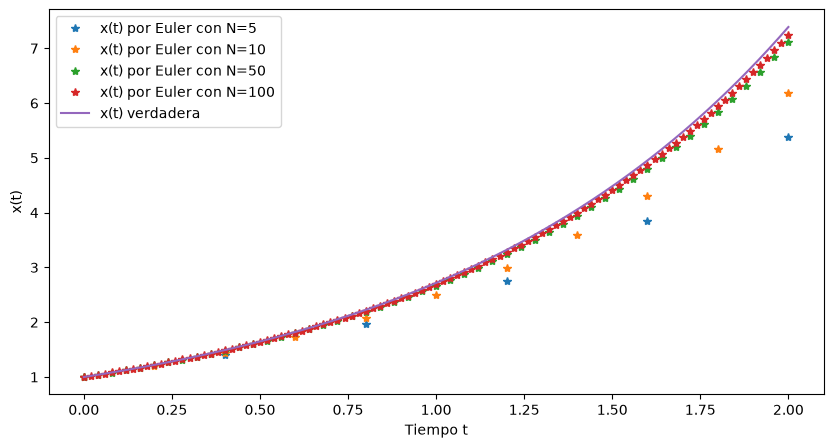

In [ ]:
# Aproximo por Euler explícito la sol. de la ec. dif. que me dan.

# defino la función que le tengo que pasar al método de Euler
def func(t,x):
  y = x
  return y


# resuelvo y aproximo por Euler explícito
x0 = 1
t0 = 0
tf = 2

for N in [5, 10, 50, 100]:
  h = (tf-t0)/N
  vals_t, vals_x = metodo_euler_explicito(x0, t0, h, func, N)

  # grafico la aproximación de Euler explícito
  plt.plot(vals_t ,vals_x, '*', label='x(t) por Euler con N={}'.format(N))

  print("Aproximación de x(2) con N =", N, "pasos:", vals_x[-1], "  error:", abs(vals_x[-1] - np.exp(2)))

print("Valor exacto x(2) = e^2 =", np.exp(2))


# grafico la solución exacta
vals_t_graf = np.linspace(0,2,10000)
vals_x_func = np.exp(vals_t_graf)
plt.plot(vals_t_graf, vals_x_func, label='x(t) verdadera')


#algo de estética
plt.xlabel('Tiempo t')
plt.ylabel('x(t)')

plt.legend() #para mostrar los labels

## Ejercicio

### Consideremos el PVI:

$$
\begin{cases}
x'(t)&=t\cos(x(t))\\
x(0)&=3
\end{cases}
$$

1. ### En papel: calcular el tamaño del paso a priori necesario para estimar $x(2)$ con un error menor a $10^{-3}$ usando el método de Euler. (Mirar error global de Euler de la teórica).

1. ### Usar el método de Euler explícito para aproximar la solución del PVI con $t$ entre 0 y 2, para el tamaño de paso averiguado en el ítem anterior. Graficar los resultados obtenidos.

Cantidad de pasos 142857
Aproximación de x(2): 1.8045503112523407


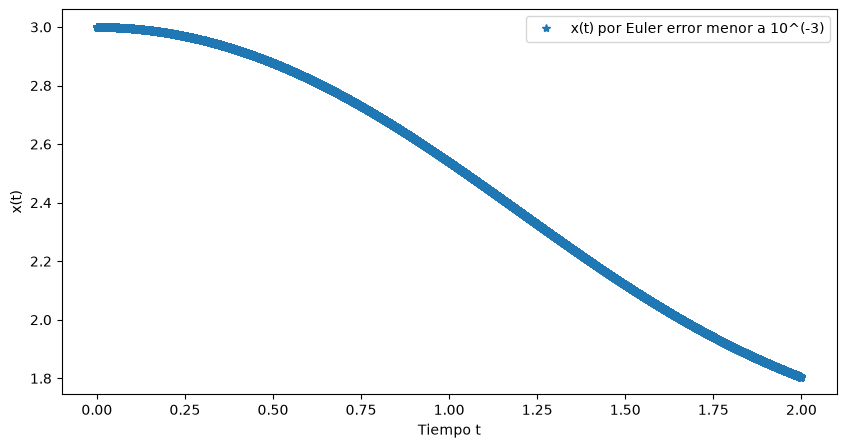

In [ ]:
# defino la función
def func(t,x):
  y = t*np.cos(x)
  return y


# aproximo la sol. por Euler explícito
x0 = 3
t0 = 0
tf = 2

# Acá va el h que calculé en papel
# El Error global de Euler no lo llegamos a ver, con lo cual lo ponemos de prepo
h = 1.4*10**(-5)
# h = 10**(-6) #probar este y ver como aumenta MUCHO la cantidad de pasos
N = int( (tf-t0)/h ) #devuelve parte entera: detalle técnico para que N sea entero y el range no se queje.

# resolver por Euler
vals_t, vals_x = metodo_euler_explicito(x0, t0, h, func, N)

# graficar la solución que da Euler
plt.plot(vals_t ,vals_x, '*', label='x(t) por Euler error menor a 10^(-3)')

# estética para el gráfico
plt.xlabel('Tiempo t')
plt.ylabel('x(t)')
plt.legend()

print('Cantidad de pasos', N) #¡son muchos! ¿por qué?
print('Aproximación de x(2):', vals_x[-1])